# Gaussian noise 추가
원본 multi-echo GRE complex 데이터의 Real과 Imaginary 성분에 독립적인 Gaussian noise를 추가합니다.

생성할 실험 데이터:
- 0% : 원본 데이터이므로 별도 저장하지 않음
- 10%, 30%, 50% : noise가 추가된 데이터를 각각 `.mat` 파일로 저장

생성된 데이터는 이후 Magnitude MP-PCA와 Real/Imaginary MP-PCA의 공통 입력으로 사용합니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. 환경설정

In [2]:
from pathlib import Path
import gc
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat, whosmat

# 프로젝트 경로
PROJECT_ROOT = Path('/content/drive/MyDrive/project-lab')
ORIGINAL_PATH = PROJECT_ROOT / "data" / "meas_gre_dir1.mat"
OUTPUT_DIR = PROJECT_ROOT / "results" / "noisy"

# 조건
NOISE_LEVELS = [10, 30, 50]
SEED = 42
SLICE_INDEX = 88
ECHO_INDEX = 0

# True이면 파일 크기는 줄지만 저장 시간이 크게 늘어날 수 있습니다.
SAVE_COMPRESSED = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert ORIGINAL_PATH.exists(), f'파일을 찾을 수 없습니다: {ORIGINAL_PATH}'

print('원본 파일: ', ORIGINAL_PATH)
print('결과 폴더: ', OUTPUT_DIR)
print('Noise levels: ', NOISE_LEVELS)
print('Random seed: ', SEED)

원본 파일:  /content/drive/MyDrive/project-lab/data/meas_gre_dir1.mat
결과 폴더:  /content/drive/MyDrive/project-lab/results/noisy
Noise levels:  [10, 30, 50]
Random seed:  42


## 2. 원본 complex 데이터 불러오기
필요한 변수만 불러와 메모리 사용량을 줄입니다.
- meas_gre : 원본 4차원 complex MRI 데이터
- mask_brain : 뇌 영역 마스크
- te_gre : 각 echo의 echo time

In [4]:
print('원본 MAT 파일 변수 목록')
for name, shape, dtype in whosmat(ORIGINAL_PATH):
  print(f'- {name}: shape={shape}, type={dtype}')

mat = loadmat(
    ORIGINAL_PATH,
    variable_names=['meas_gre', 'mask_brain', 'te_gre']
)

image = mat['meas_gre']
mask = mat['mask_brain'].astype(bool)
te_gre = mat.get('te_gre')
del mat

# 데이터 구조가 예상과 다르면 여기서 실행을 중단합니다.
assert image.ndim == 4, f'4D 데이터가 아닙니다: {image.shape}'
assert np.iscomplexobj(image), f'complex 데이터가 아닙니다: {image.dtype}'
assert mask.shape == image.shape[:3], (mask.shape, image.shape)
assert 0 <= SLICE_INDEX < image.shape[2]
assert 0 <= ECHO_INDEX < image.shape[3]

print('\nMRI shape: ', image.shape)
print('MRI dtype: ', image.dtype)
print('Complex 여부: ', np.iscomplexobj(image))
print('Mask shape: ', mask.shape)

원본 MAT 파일 변수 목록
- B0_dir: shape=(1, 3), type=double
- CF: shape=(1, 1), type=double
- delta_TE: shape=(1, 1), type=double
- mask_brain: shape=(256, 224, 176), type=double
- meas_gre: shape=(256, 224, 176, 6), type=double
- te_gre: shape=(6, 1), type=double
- tolvalue: shape=(1, 1), type=double
- voxel_size_gre: shape=(3, 1), type=double

MRI shape:  (256, 224, 176, 6)
MRI dtype:  complex128
Complex 여부:  True
Mask shape:  (256, 224, 176)


## 3. Noise 크기의 기준 계산

각 echo에서 뇌 마스크 내부의 평균 magnitude를 계산한 뒤, 6개 echo의 평균을 전체 신호 기준으로 사용합니다.

Noise 표준편차 계산식:

    sigma = 뇌 영역의 전체 평균 magnitude × noise level / 100

예를 들어 10% noise는 평균 신호의 10%를 Gaussian noise의 표준편차로 사용한다는 뜻입니다.

In [7]:
echo_means = []

for echo in range(image.shape[-1]):
  echo_mean = float(np.abs(image[..., echo][mask]).mean())
  echo_means.append(echo_mean)
  print(f'Echo {echo}: mean magnitude = {echo_mean:.8f}')

overall_mean = float(np.mean(echo_means))
print(f'\n전체 echo 평균 magnitude = {overall_mean:.8f}')

for level in NOISE_LEVELS:
  sigma = overall_mean * level / 100.0
  print(f'{level}% noise -> sigma = {sigma:.8f}')

Echo 0: mean magnitude = 3.79706846
Echo 1: mean magnitude = 3.46144223
Echo 2: mean magnitude = 3.15238420
Echo 3: mean magnitude = 2.87244516
Echo 4: mean magnitude = 2.62019980
Echo 5: mean magnitude = 2.38848753

전체 echo 평균 magnitude = 3.04867123
10% noise -> sigma = 0.30486712
30% noise -> sigma = 0.91460137
50% noise -> sigma = 1.52433562


## 4. Noise 생성·저장·시각화 함수

Real과 Imaginary에 서로 독립적인 Gaussian noise를 추가합니다.

중요한 조건:
- 원본 image에는 직접 값을 더하지 않으므로 원본 데이터는 변경되지 않습니다.
- 뇌 마스크 내부에만 noise를 추가합니다.
- 각 noise level에서 동일한 seed를 사용하므로 noise 모양은 같고 크기만 달라집니다.
- 저장 용량을 줄이기 위해 noisy_complex를 중복 저장하지 않고 noisy_real과 noisy_imag만 저장합니다.
- 필요할 때 noisy_real + 1j * noisy_imag로 complex 데이터를 복원할 수 있습니다.

In [11]:
def add_complex_gaussian_noise(image, mask, sigma, seed):
  rng = np.random.default_rng(seed)
  mask4d = mask[..., None]

  # copy=True로 새 배열을 만들어 원본 image를 보호합니다.
  noisy_real = image.real.astype(np.float32, copy=True)
  real_noise = rng.standard_normal(image.shape, dtype=np.float32)
  real_noise *= np.float32(sigma)
  real_noise *= mask4d
  noisy_real += real_noise
  del real_noise

  noisy_imag = image.imag.astype(np.float32, copy=True)
  imag_noise = rng.standard_normal(image.shape, dtype=np.float32)
  imag_noise *= np.float32(sigma)
  imag_noise *= mask4d
  noisy_imag += imag_noise
  del imag_noise

  return noisy_real, noisy_imag


def save_noisy_data(path, noisy_real, noisy_imag, mask, te_gre, level, sigma, seed):
  result = {
      'noisy_real': noisy_real,
      'noisy_imag': noisy_imag,
      'mask_brain': mask.astype(np.uint8),
      'noise_level_percent': np.array([[level]], dtype=np.int16),
      'sigma': np.array([[sigma]], dtype=np.float64),
      'seed': np.array([[seed]], dtype=np.int64),
  }
  if te_gre is not None:
    result['te_gre'] = te_gre

  savemat(path, result, do_compression=SAVE_COMPRESSED)


def show_noise_preview(image, noisy_real, noisy_imag, mask, level, sigma):
  original2d = np.abs(image[:, :, SLICE_INDEX, ECHO_INDEX])
  noisy2d = np.hypot(
      noisy_real[:, :, SLICE_INDEX, ECHO_INDEX],
      noisy_imag[:, :, SLICE_INDEX, ECHO_INDEX],
  )
  mask2d = mask[:, :, SLICE_INDEX]

  # 원본과 noisy 영상을 같은 밝기 범위로 표시합니다.
  vmin, vmax = np.percentile(original2d[mask2d], [1, 99])
  difference = noisy2d - original2d
  limit = max(float(np.percentile(np.abs(difference[mask2d]), 99)), 1e-12)

  fig, axes = plt.subplots(1, 3, figsize=(13, 4))
  axes[0].imshow(original2d.T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
  axes[0].set_title('Original magnitude')
  axes[1].imshow(noisy2d.T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
  axes[1].set_title(f'Noisy magnitude ({level}%)')
  axes[2].imshow(difference.T, cmap='RdBu_r', origin='lower', vmin=-limit, vmax=limit)
  axes[2].set_title('Noisy - Original')

  for ax in axes:
    ax.axis('off')

  fig.suptitle(f'Noise {level}% | sigma={sigma:.6g} | seed={SEED}')
  plt.tight_layout()
  preview_path = OUTPUT_DIR / f'noise_preview_{level:02d}.png'
  plt.savefig(preview_path, dpi=160, bbox_inches='tight')
  plt.show()
  plt.close(fig)

## 5. 10%, 30%, 50% noisy 데이터 생성

각 level을 한 번에 하나씩 생성하고 저장한 뒤 메모리에서 제거합니다. Colab RAM 사용량을 줄이기 위한 처리입니다.

처음 실행할 때는 NOISE_LEVELS를 [10]으로 바꾸어 10%만 시험한 후 전체를 실행해도 됩니다.


===== Noise 10% 생성 =====
sigma = 0.30486712
저장 중:  /content/drive/MyDrive/project-lab/results/noisy/noisy_10.mat


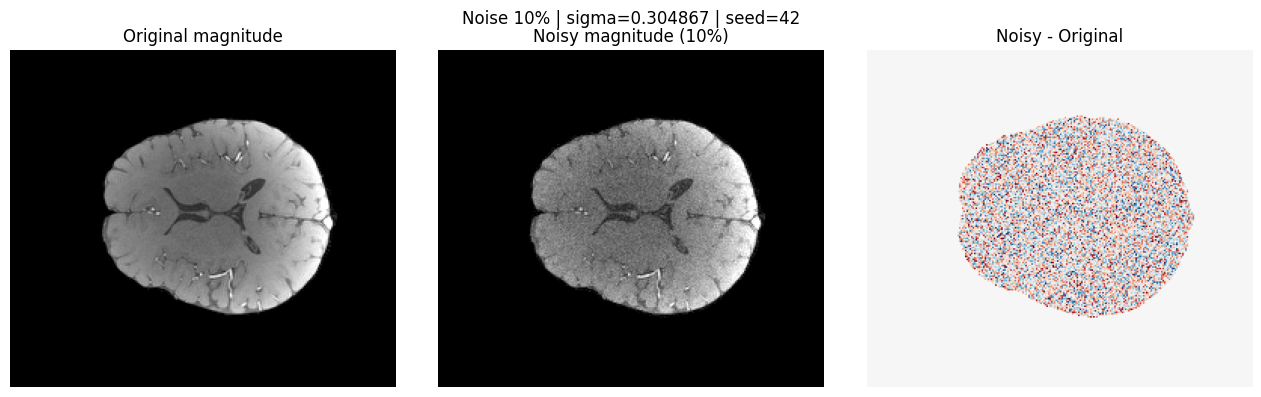

10% 저장 완료

===== Noise 30% 생성 =====
sigma = 0.91460137
저장 중:  /content/drive/MyDrive/project-lab/results/noisy/noisy_30.mat


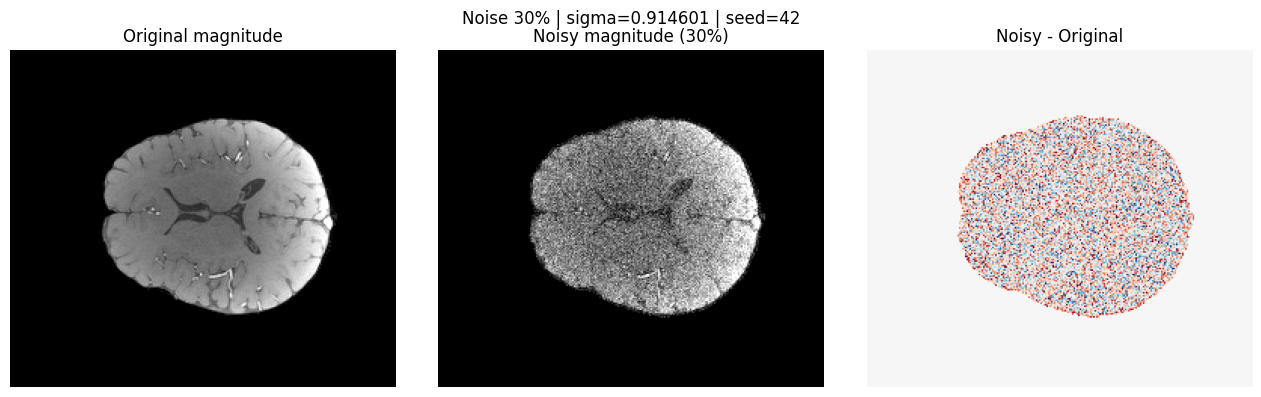

30% 저장 완료

===== Noise 50% 생성 =====
sigma = 1.52433562
저장 중:  /content/drive/MyDrive/project-lab/results/noisy/noisy_50.mat


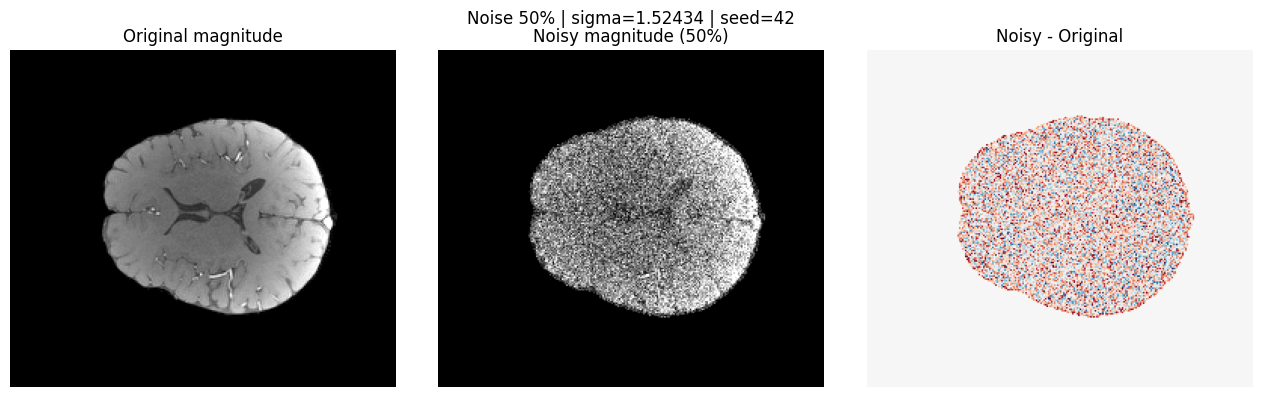

50% 저장 완료

모든 noise level 생성 완료


In [12]:
saved_files = []

for level in NOISE_LEVELS:
  sigma = overall_mean * level / 100.0
  output_path = OUTPUT_DIR / f'noisy_{level:02d}.mat'

  print(f'\n===== Noise {level}% 생성 =====')
  print(f'sigma = {sigma:.8f}')

  noisy_real, noisy_imag = add_complex_gaussian_noise(
      image=image,
      mask=mask,
      sigma=sigma,
      seed=SEED,
  )

  print('저장 중: ', output_path)
  save_noisy_data(
      path=output_path,
      noisy_real=noisy_real,
      noisy_imag=noisy_imag,
      mask=mask,
      te_gre=te_gre,
      level=level,
      sigma=sigma,
      seed=SEED,
  )

  show_noise_preview(
      image=image,
      noisy_real=noisy_real,
      noisy_imag=noisy_imag,
      mask=mask,
      level=level,
      sigma=sigma,
  )

  saved_files.append(output_path)
  del noisy_real, noisy_imag
  gc.collect()
  print(f'{level}% 저장 완료')

print('\n모든 noise level 생성 완료')

## 6. 저장 결과 확인

대용량 배열을 다시 불러오지 않고 파일 크기와 내부 변수 목록만 확인합니다.

각 MAT 파일의 noisy_real과 noisy_imag를 다음과 같이 결합하면 noisy complex 데이터를 복원할 수 있습니다.

    noisy_complex = noisy_real + 1j * noisy_imag

In [13]:
for path in saved_files:
  size_mib = path.stat().st_size / (1024 ** 2)
  print(f'\n{path.name}: {size_mib:.1f} MiB')

  for name, shape, dtype in whosmat(path):
    print(f' - {name}: shape={shape}, type={dtype}')

print('\n결과 확인 완료')


noisy_10.mat: 471.6 MiB
 - noisy_real: shape=(256, 224, 176, 6), type=single
 - noisy_imag: shape=(256, 224, 176, 6), type=single
 - mask_brain: shape=(256, 224, 176), type=uint8
 - noise_level_percent: shape=(1, 1), type=int16
 - sigma: shape=(1, 1), type=double
 - seed: shape=(1, 1), type=int64
 - te_gre: shape=(6, 1), type=double

noisy_30.mat: 471.6 MiB
 - noisy_real: shape=(256, 224, 176, 6), type=single
 - noisy_imag: shape=(256, 224, 176, 6), type=single
 - mask_brain: shape=(256, 224, 176), type=uint8
 - noise_level_percent: shape=(1, 1), type=int16
 - sigma: shape=(1, 1), type=double
 - seed: shape=(1, 1), type=int64
 - te_gre: shape=(6, 1), type=double

noisy_50.mat: 471.6 MiB
 - noisy_real: shape=(256, 224, 176, 6), type=single
 - noisy_imag: shape=(256, 224, 176, 6), type=single
 - mask_brain: shape=(256, 224, 176), type=uint8
 - noise_level_percent: shape=(1, 1), type=int16
 - sigma: shape=(1, 1), type=double
 - seed: shape=(1, 1), type=int64
 - te_gre: shape=(6, 1), type